In [1]:
!pwd
import sys
sys.path.append("..")

/users/khordadi/truejit/evaluation/compilation-plan/profiling-accuracy


In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif"],
})

In [3]:
from pathlib import Path
from solver import *
from profiling import *
import numpy as np

In [4]:
benchmark = ffmpeg

In [5]:
# generate_static_info(benchmark.binary)

In [6]:
static_info = get_static_info(benchmark.binary)
static_info

,id,name,size.bytecode,size.static
0,24,__wasm_call_ctors,8,864
1,25,undefined_weak:__wasilibc_find_relpath_alloc,4,504
2,26,_start,69,984
3,27,__SIG_IGN,3,512
4,28,__SIG_ERR,5,504
...,...,...,...,...
27485,27509,ff_tx_fft16_ns_int32_c,2188,3344
27486,27510,ff_tx_fft8_ns_int32_c,1144,2096
27487,27511,ff_tx_fft4_ns_int32_c,382,912
27488,27512,ff_tx_fft2_ns_int32_c,163,664


In [ ]:
import matplotlib.pyplot as plt

# gather normalized data for all workloads to compute global x limits
all_data = []
for wl in benchmark.workloads:
    p = Profile(profiles_root(benchmark.binary, wl.name, 'interp'))
    d = np.array(p.e2e, dtype=float) / 1e9
    d = d / np.mean(d)
    all_data.append(d)

concat = np.concatenate(all_data)
min_v, max_v = concat.min(), concat.max()
max_dev = max(max_v - 1, 1 - min_v)
xlim = (1 - max_dev * 1.1, 1 + max_dev * 1.1)

fig, ax = plt.subplots(1, 1, figsize=(6, 5), dpi=320)

y_offset = 0
y_ticks = []
y_labels = []

for idx, workload in enumerate(benchmark.workloads):
    data = all_data[idx]
    
    # plot boxplot and scatter at current y offset
    positions = [y_offset]
    ax.boxplot(data, vert=False, positions=positions, widths=0.6)
    ax.scatter(data, np.full_like(data, y_offset, dtype=float), s=12, alpha=0.8, 
               color='tab:blue', edgecolors='black', linewidths=0.2, zorder=3)
    
    y_ticks.append(y_offset)
    y_labels.append(workload.name)
    y_offset += 1

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_xlim(xlim)
ax.axvline(1.0, color='tab:red', linestyle='--', linewidth=0.8, zorder=4)
ax.set_xlabel('E2E Time (relative to mean, centered at 1)')

plt.tight_layout()
plt.show()


In [ ]:
generate_profile_oracle(benchmark)
generate_profile_union(benchmark)
generate_plans(benchmark)

In [ ]:
base_profile = pd.read_csv(profiles_root(benchmark.binary, benchmark.workloads[0].name) / 'profile.csv')
base_profile

In [ ]:
plan = plan_json_to_df(plans_root(benchmark.binary, benchmark.workloads[0].name, 'min_e2e.unconstrained.default_static') / 'oracle.json')
plan

In [ ]:
pe = PlanEvaluation(static_info, base_profile, plan)
pe.e2e

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(benchmark.workloads), 1, figsize=(10, 1 * len(benchmark.workloads)), dpi=320)

for idx, wl in enumerate(benchmark.workloads):
    base_profile = pd.read_csv(profiles_root(benchmark.binary, wl.name) / 'profile.csv')
    plan = plan_json_to_df(plans_root(benchmark.binary, wl.name, 'min_e2e.unconstrained.default_static') / 'oracle.json')
    pe = PlanEvaluation(static_info, base_profile, plan)
    estimation = pe.e2e
    
    actual_profile = Profile(profiles_root(benchmark.binary, wl.name, 'min_e2e.unconstrained.default_static/oracle'))
    actuals = actual_profile.e2e

    # make them in s (it's ns now)
    actuals = [x / 1e9 for x in actuals]
    estimation = estimation / 1e9

    # plot on the corresponding subplot
    axes[idx].boxplot(actuals, vert=False)
    axes[idx].axvline(estimation, color='tab:blue', linestyle='--', linewidth=1, label='Estimated E2E Time', zorder=3)   
    axes[idx].set_xlabel('E2E Time (s)')
    axes[idx].set_title(f'{wl.name} ({len(actuals)} runs)')
    axes[idx].set_xlim(-10, 150)

    # remove y-axis ticks and labels
    axes[idx].set_yticks([])
    # axes[idx].grid(axis='x')
axes[idx].legend()

plt.tight_layout()
plt.show()


In [7]:
out_root = Path("out")
out_root.mkdir(exist_ok=True)

profiles_dir = out_root / "profiles"
plan_path = out_root / "plan.json"

In [ ]:
recorder = Recorder()


for wl in benchmark.workloads:
    profiles_path = profiles_dir / wl.name

    profiles_path.mkdir(parents=True, exist_ok=True)

    base_profile = pd.read_csv(profiles_root(benchmark.binary, wl.name) / 'profile.csv')

    planner = Planner(EndToEndTime(), [], "static")
    planner.plan(static_info, base_profile)
    planner.to_json(plan_path)

    for r in range(3):
        recorder.record(
            benchmark.binary,
            wl,
            options=[
                "--interp=planned",
                "--async=planned",
                "--static=planned",
                "--specialize=planned",
            ],
            profile_path=profiles_path.absolute(),
            env={"PLAN": plan_path.absolute()},
        )

In [8]:
predicted_e2es = []
actual_e2es = []
y_labels = []

for wl in benchmark.workloads:
    profiles_path = profiles_dir / wl.name
    base_profile = pd.read_csv(profiles_root(benchmark.binary, wl.name) / 'profile.csv')

    planner = Planner(EndToEndTime(), [], "static")
    plan = planner.plan(static_info, base_profile)
    history = get_history(benchmark.binary, wl.name, 'jit')
    evaluator = PlanEvaluation(static_info, base_profile, plan, history)

    profile = Profile(profiles_path)
    predicted_e2e = float(evaluator.e2e)

    predicted_e2es.append(predicted_e2e)
    actual_e2es.append(np.array(profile.e2e, dtype=float))
    y_labels.append(wl.name)

[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.13 seconds
[plan evaluation] merged static_info | base_profile: 27490 rows
[plan evaluation] merged static_info | base_profile | plan: 27490 rows
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.13 seconds
[plan evaluation] merged static_info | base_profile: 27490 rows
[plan evaluation] merged static_info | base_profile | plan: 27490 rows
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.10 seconds
[plan evaluation] merged static_info | base_profile: 27490 rows
[plan evaluation] merged static_info | base_profile | plan: 27490 rows
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.13 seconds
[plan evaluation] merged static_info | base_profile: 27490 rows
[plan evaluation] merged static_info | base_profile | plan: 27490 rows
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.08 seconds
[plan evaluation] merged static_info | base_profile: 27490 rows
[plan evaluation

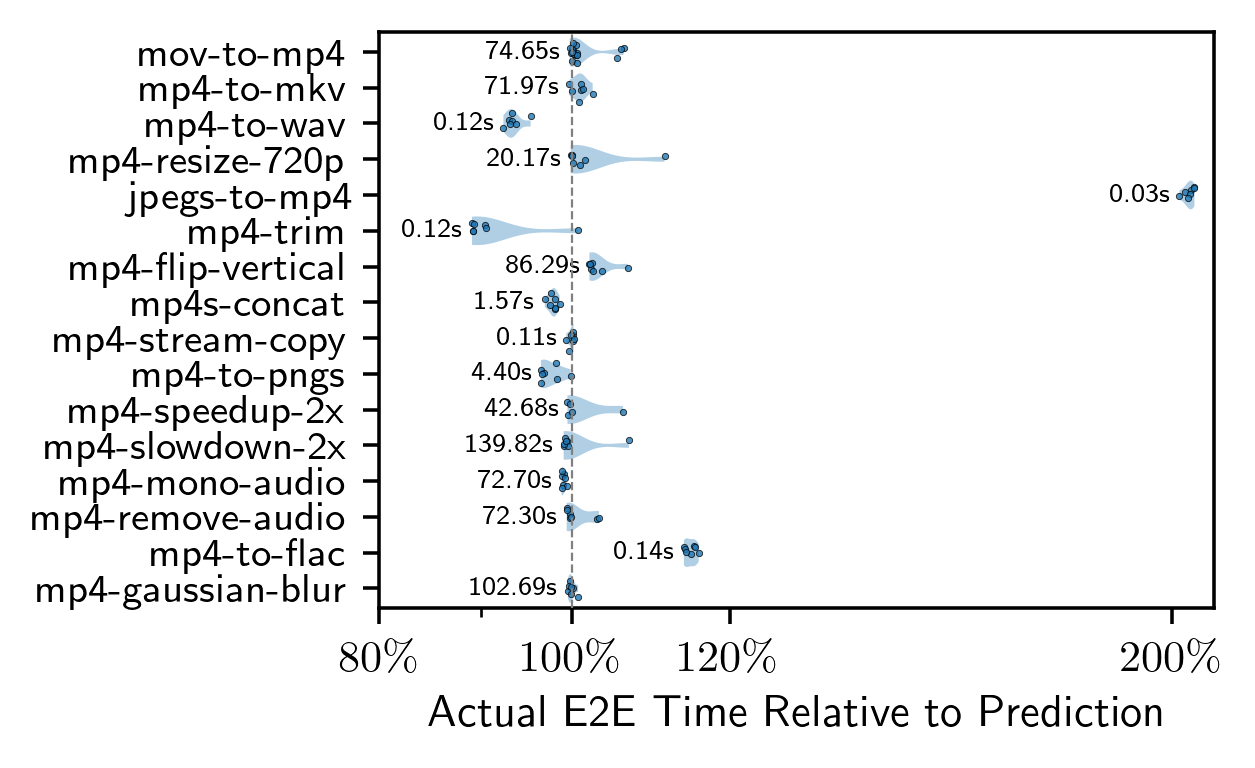

In [9]:
relative_e2es = [actual / pred for actual, pred in zip(actual_e2es, predicted_e2es)]

fig, ax = plt.subplots(1, 1, figsize=(4, 2.5), dpi=320)

y_pos = np.arange(len(benchmark.workloads))

parts = ax.violinplot(
    relative_e2es,
    positions=y_pos,
    vert=False,
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)

for body in parts['bodies']:
    # body.set_facecolor('tab:blue')
    # body.set_edgecolor('black')
    body.set_alpha(0.35)
    body.set_linewidth(0.5)
    # showmedians line color black

    

if 'cmedians' in parts:
    parts['cmedians'].set_color('tab:red')
    parts['cmedians'].set_linewidth(1.2)

for y, data in zip(y_pos, relative_e2es):
    ax.scatter(
        data,
        np.random.normal(loc=y, scale=0.15, size=len(data)),  # jitter y values
        s=2,
        alpha=0.8,
        color='tab:blue',
        edgecolors='black',
        linewidths=0.2,
        zorder=3,
    )

ax.set_xscale('log')
ax.axvline(1.0, color='gray', linestyle='--', linewidth=.5, zorder=4)
ax.set_yticks(y_pos)

# add predicted absolute time (in seconds) to each row label for context
pred_seconds = [f"{p/1e9:.2f}s" for p in predicted_e2es]
annotated_labels = [f"{name}" for name in y_labels]
ax.set_yticklabels(annotated_labels, fontsize=9)

# write pred_seconds inside the plot next to max of each violin
for i ,(y, pred_sec) in enumerate(zip(y_pos, pred_seconds)):
    x = min(relative_e2es[i]) * .99  # position it slightly to the right of the max data point
    ax.text(x, y, pred_sec, fontsize=6, verticalalignment='center', horizontalalignment='right', color='black')

ax.set_xlim(0.8, 2.1)
ax.set_xticks([0.8, 1.0, 1.2, 2.0])
ax.set_xticklabels([r'$80\%$', r'$100\%$', r'$120\%$', r'$200\%$'])
ax.set_xlabel('Actual E2E Time Relative to Prediction')

# reverse y-axis to have the first workload on top
ax.invert_yaxis()

# remove y margin
plt.margins(y=0.01)

plt.tight_layout()
# to pdf
plt.savefig("out/profiling_accuracy.pdf", bbox_inches='tight', pad_inches=0.0, dpi=320, transparent=True, facecolor='white')
plt.show()
